# 02 — the CVD ↔ OI bridge

**Goal:** put the three quantities side by side — **price**, **CVD** (net taker
aggression, a *flow*), **OI** (open interest, a *stock*) — and use the classic
order-flow logic to *classify* what's happening, episode by episode.

The bridge, restated:

- **CVD** answers *who hit the market* (aggressor buy vs sell).
- **ΔOI** answers *did positions open or close* (new contract created vs
  destroyed).
- **Price** direction closes the triangle.

The 2×2 that the pump-fade work cares about:

| price | OI | reading |
|-------|----|---------|
| ↑ | ↑ | **new longs opening** — fresh money, trend-backed |
| ↑ | ↓ | **short covering** — rally on closing, often fades |
| ↓ | ↑ | **new shorts opening** — fresh bearish money |
| ↓ | ↓ | **longs closing / liquidating** — bulls bailing |

OI updates ~every 9s on Bybit, so we work on a **1-minute grid** here.

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import *
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

SESS = "2026-07-09T08-03-30Z"
SYM  = "BTCUSDT"

tr = load(SESS, "trades",    SYM, with_datetime=True)
ob = load(SESS, "orderbook", SYM, with_datetime=True)
tk = load(SESS, "ticker",    SYM, with_datetime=True)

# signed taker volume -> CVD (from nb01)
sign = np.where(tr['side'] == 'buy', 1.0, np.where(tr['side'] == 'sell', -1.0, 0.0))
tr = tr.assign(signed=sign * tr['amount'], cvd=lambda d: (sign * d['amount']).cumsum())
print(f"{len(tr):,} trades, {len(tk):,} ticker rows")

1,325,127 trades, 375,103 ticker rows


## 1. Align everything on a 1-minute grid

- **price** — last mid in the minute.
- **CVD**   — last cumulative value in the minute (so ΔCVD over the minute =
  net taker flow that minute, in BTC).
- **OI**    — last open interest in the minute (BTC).

Then take the per-minute *changes* — those are what the 2×2 classifies.

In [2]:
GRID = "1min"
g = pd.DataFrame({
    "price": mid(ob).resample(GRID).last(),
    "cvd":   tr['cvd'].resample(GRID).last(),
    "oi":    tk['open_interest'].resample(GRID).last(),
}).ffill().dropna()

g["d_price"] = g["price"].diff()
g["d_cvd"]   = g["cvd"].diff()          # net taker BTC this minute
g["d_oi"]    = g["oi"].diff()           # net contracts opened(+)/closed(-)
g = g.dropna()
print(f"{len(g)} one-minute bins")
print(f"session net: price {g['price'].iloc[-1]-g['price'].iloc[0]:+.0f} USDT, "
      f"OI {g['oi'].iloc[-1]-g['oi'].iloc[0]:+.0f} BTC, "
      f"CVD {g['cvd'].iloc[-1]-g['cvd'].iloc[0]:+.0f} BTC")
g[["price","d_price","d_cvd","d_oi"]].head()

858 one-minute bins
session net: price +349 USDT, OI -1055 BTC, CVD +649 BTC


,price,d_price,d_cvd,d_oi
dt,,,,
2026-07-09 08:04:00+00:00,62972.05,17.1,2.879,0.140
2026-07-09 08:05:00+00:00,62928.15,-43.9,-26.728,-5.331
2026-07-09 08:06:00+00:00,62935.65,7.5,2.658,3.269
2026-07-09 08:07:00+00:00,62960.65,25.0,15.059,2.864
2026-07-09 08:08:00+00:00,62935.15,-25.5,0.099,-1.174


## 2. Classify every minute into the 2×2

Label each minute by `sign(Δprice) × sign(ΔOI)`, then look at how many minutes
fall in each cell and what the **taker flow (ΔCVD)** looked like there. The CVD
column is the tell: e.g. "price↑ OI↑" *should* come with positive CVD
(aggressive buyers opening longs); "price↑ OI↓" (short covering) is buyers
lifting to *close* shorts — also positive CVD but shrinking OI.

In [3]:
def quad(dp, doi):
    p = "up" if dp > 0 else "down"
    o = "OI+" if doi > 0 else "OI-"
    return f"{p} {o}"

LABELS = {
    "up OI+":   "new longs opening",
    "up OI-":   "short covering",
    "down OI+": "new shorts opening",
    "down OI-": "longs closing / liq",
}
g["quad"] = [quad(dp, doi) for dp, doi in zip(g["d_price"], g["d_oi"])]

tbl = g.groupby("quad").agg(
    minutes=("quad", "size"),
    mean_dCVD=("d_cvd", "mean"),
    mean_dOI=("d_oi", "mean"),
    mean_dPrice=("d_price", "mean"),
).reindex(["up OI+","up OI-","down OI+","down OI-"])
tbl["reading"] = [LABELS[k] for k in tbl.index]
tbl = tbl.round(2)
print(tbl.to_string())
print(f"\ntotal minutes: {len(g)}   (share by cell)")
print((100*tbl['minutes']/len(g)).round(1).to_string())

          minutes  mean_dCVD  mean_dOI  mean_dPrice              reading
quad                                                                    
up OI+        217      11.43     14.80        24.95    new longs opening
up OI-        211      10.02    -13.33        24.63       short covering
down OI+      197      -4.40     12.82       -23.48   new shorts opening
down OI-      233     -13.21    -17.07       -24.11  longs closing / liq

total minutes: 858   (share by cell)
quad
up OI+      25.3
up OI-      24.6
down OI+    23.0
down OI-    27.2


## 3. The picture — price / CVD / OI stacked

Three panels, shared time axis. Shaded bands on the price panel mark the two
"rally" regimes so you can see, when price is rising, whether OI is **rising
with it** (new longs, green tint) or **falling** (short covering, orange tint).

[saved] microstructure\initial\_out\02_price_cvd_oi.png


WindowsPath('C:/projects/researchlab/microstructure/initial/_out/02_price_cvd_oi.png')

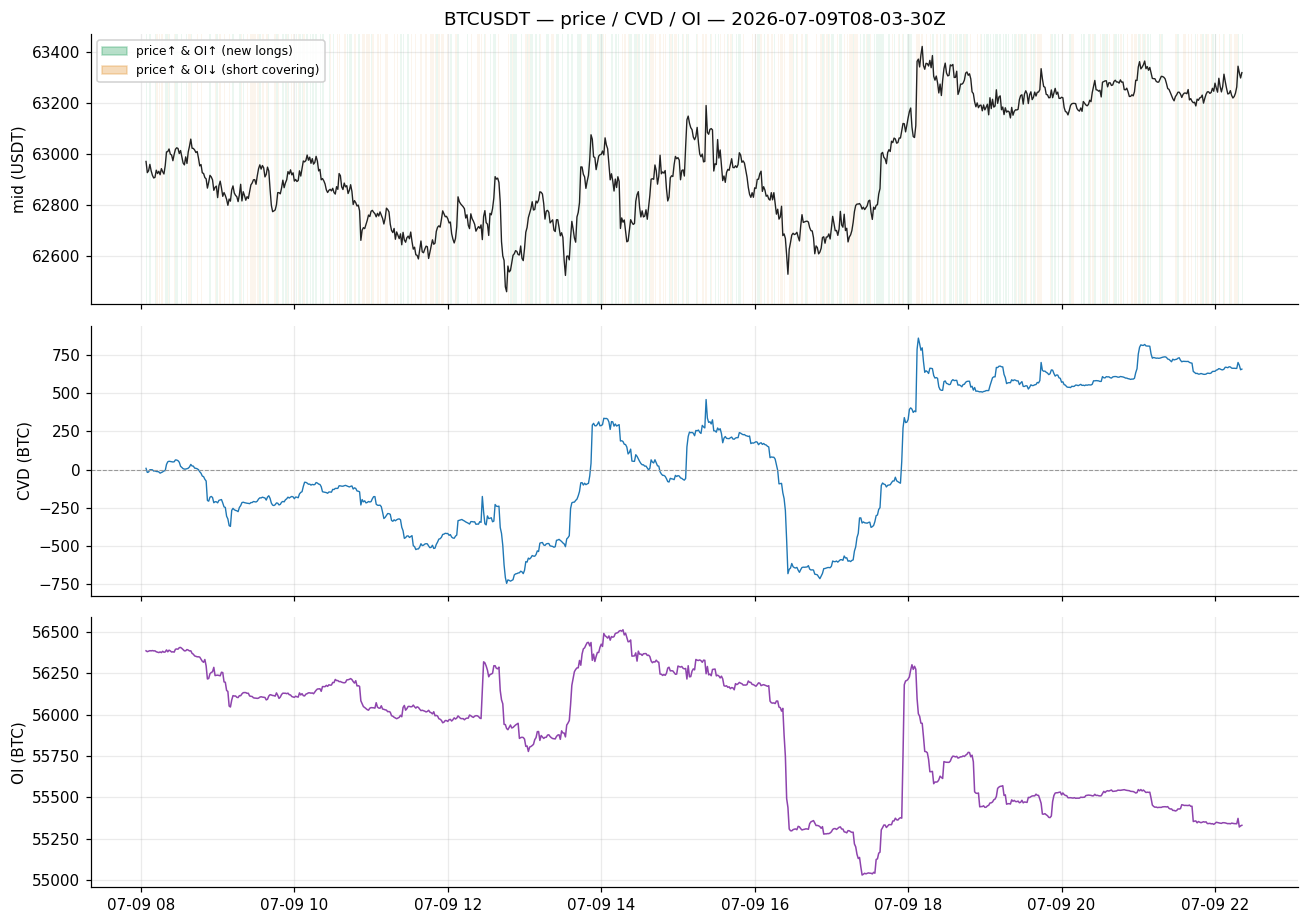

In [4]:
fig, (a1, a2, a3) = plt.subplots(3, 1, figsize=(12, 8.5), sharex=True)

a1.plot(g.index, g["price"], color="#222", lw=0.9)
a1.set_ylabel("mid (USDT)")
a1.set_title(f"{SYM} — price / CVD / OI — {SESS}")
# tint minutes by rally regime
up = g["d_price"] > 0
for t, is_up, doi in zip(g.index, up, g["d_oi"]):
    if is_up:
        a1.axvspan(t, t + pd.Timedelta(GRID),
                   color=("#159a52" if doi > 0 else "#e08a1e"), alpha=0.08, lw=0)

a2.plot(g.index, g["cvd"], color="#1f77b4", lw=0.9)
a2.axhline(0, color="#999", lw=0.7, ls="--")
a2.set_ylabel("CVD (BTC)")

a3.plot(g.index, g["oi"], color="#8e44ad", lw=1.0)
a3.set_ylabel("OI (BTC)")

# legend proxy
from matplotlib.patches import Patch
a1.legend(handles=[Patch(color="#159a52", alpha=0.3, label="price↑ & OI↑ (new longs)"),
                   Patch(color="#e08a1e", alpha=0.3, label="price↑ & OI↓ (short covering)")],
          loc="upper left", framealpha=0.9, fontsize=8)
show("02_price_cvd_oi")

## 4. Reading & verdict

*(fill after run)* — Read the three panels together:
- Price panel with green/orange tint shows which rallies were backed by **new
  longs** vs which were **short covering**.
- CVD slope = instantaneous taker pressure; OI level = how much position is on
  the books.
- The 2×2 table quantifies the mix over the session.

**Session headline:** the day closed **price ↑ but OI ↓** overall — a net
**de-risking / short-covering** drift rather than fresh leveraged longs piling
in. That's exactly the distinction OI adds on top of CVD.

**Honest caveats:** one calm BTC session (no pump to stress-test the "froth vs
squeeze" split); OI is 9s-resolution so 1-min bins are the finest honest grid;
descriptive classification, not a signal; ΔOI sign only — we don't know the
passive side's intent per trade, only the aggregate.

**Where this points:**
1. **The realtime polygon** (next) — watch CVD + ΔOI + tape live to build
   intuition on many regimes, since one recorded session is thin.
2. Later: re-run this bridge on a **pump** episode (capture one, or find one in
   a longer session) — that's where "price↑ OI↑ froth" vs "price↑ OI↓ squeeze"
   earns its keep for the fade edge.